# Netflix Movies & TV Shows - Exploratory Data Analysis (EDA)

## Project Overview
This project explores Netflix Movies and TV Shows dataset to extract meaningful insights about content distribution, trends, genres, ratings, and country contributions.

The goal is to perform Exploratory Data Analysis (EDA) using Python and visualize patterns for business insights.

---

## Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

---

## Dataset Source
Kaggle Netflix Titles Dataset

In [2]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset
We begin by loading the dataset into a Pandas DataFrame for analysis.

In [3]:
# Load dataset
df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## Understanding the Dataset
We inspect dataset structure, missing values, and duplicates.

In [4]:
df.info()  # Displays dataset structure including column names, data types, and non-null counts

df.isnull().sum()  # Shows the total number of missing values in each column

df.duplicated().sum()  # Returns the total number of duplicate rows in the dataset

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


np.int64(0)

## Data Cleaning
In this section, we clean and prepare the dataset for analysis by handling missing values,
correcting data types, and creating new features for deeper insights.

### Steps performed:
- Filled missing values in key categorical columns
- Removed rows with missing critical fields
- Converted date columns to proper datetime format
- Extracted useful time-based features

In [5]:
# Fill missing categorical values
df[['director', 'cast', 'country']] = df[['director', 'cast', 'country']].fillna("Unknown")

# Remove rows with missing critical fields
df = df.dropna(subset=['date_added', 'rating', 'duration']).copy()

# Convert date column to datetime format
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Extract year from date_added
df['year_added'] = df['date_added'].dt.year

# Convert release year to numeric type
df['release_year'] = pd.to_numeric(df['release_year'], errors='coerce')

# Reset index after cleaning
df.reset_index(drop=True, inplace=True)

## SUMMARY STATISTICS 

This section provides key descriptive statistics about the Netflix dataset.  
It highlights important distribution insights such as the most common release year, dataset range of years, and overall content counts.

### What is included:
- Most frequently occurring release year (mode)
- Oldest and newest release years in the dataset
- Total number of titles
- Breakdown of Movies and TV Shows

These metrics help in understanding the general structure and time distribution of Netflix content.

In [6]:
# summary statistics

print("\n================ SUMMARY STATISTICS ================\n")

# Most common release year (mode)
most_common_year = df['release_year'].mode()[0]

# Oldest and newest release years
oldest_year = df['release_year'].min()
newest_year = df['release_year'].max()

# Display results
print(f"Most Common Release Year : {most_common_year}")
print(f"Oldest Release Year      : {oldest_year}")
print(f"Newest Release Year      : {newest_year}")

# Total counts
print(f"Total Titles             : {len(df)}")
print(f"Total Movies             : {(df['type'] == 'Movie').sum()}")
print(f"Total TV Shows           : {(df['type'] == 'TV Show').sum()}")


================ SUMMARY STATISTICS ================

Most Common Release Year : 2018
Oldest Release Year      : 1925
Newest Release Year      : 2021
Total Titles             : 8790
Total Movies             : 6126
Total TV Shows           : 2664


## VISUALIZATION SETTINGS

This section defines the default styling and color palette used for all visualizations in this analysis. The goal is to maintain a consistent and visually appealing design across all charts.

In [7]:
#  Visualization Settings

# Set Seaborn theme for better visual clarity
sns.set_style("whitegrid")

# Define a consistent color palette for charts
PRIMARY = "#4C78A8"
SECONDARY = "#F58518"
ACCENT = "#54A24B"
DANGER = "#E45756"

## CONTENT TYPE DISTRIBUTION (Movies vs TV Shows Distribution)
We visualize the proportion of Movies and TV Shows on Netflix.

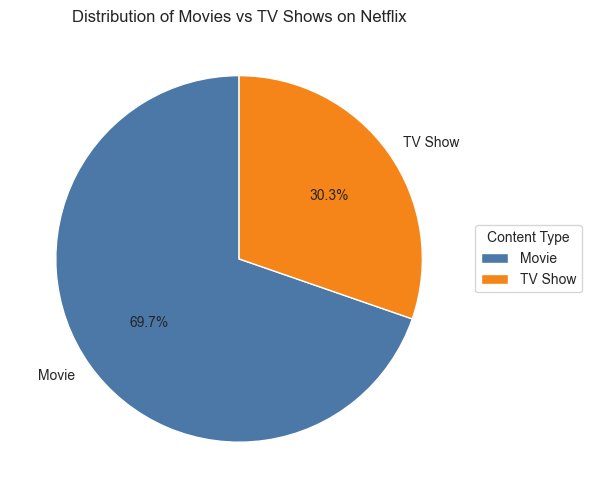

In [8]:
# VISUALIZATION 1: CONTENT TYPE DISTRIBUTION
# -------------------------------
plt.figure(figsize=(6, 6))

content_counts = df['type'].value_counts()

plt.pie(
    content_counts,
    labels=content_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=[PRIMARY, SECONDARY]
)

plt.legend(
    title="Content Type",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.title("Distribution of Movies vs TV Shows on Netflix")
plt.tight_layout()

plt.savefig("visuals/type_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## Chart 1: Distribution of Movies vs. TV Shows – Insight Interpretation

The pie chart shows that Movies dominate Netflix’s content library, accounting for 69.7% of the total catalog, while TV Shows make up 30.3%.

This indicates that Netflix places a stronger emphasis on movie content compared to TV series. However, the presence of a substantial proportion of TV shows suggests a balanced but film-weighted content strategy.

Overall, the distribution reflects Netflix’s prioritization of movies as its primary content type, while still maintaining a significant investment in TV show offerings to support diverse viewer preferences.

## CONTENT GROWTH OVER TIME
We analyze how Netflix content has grown yearly.

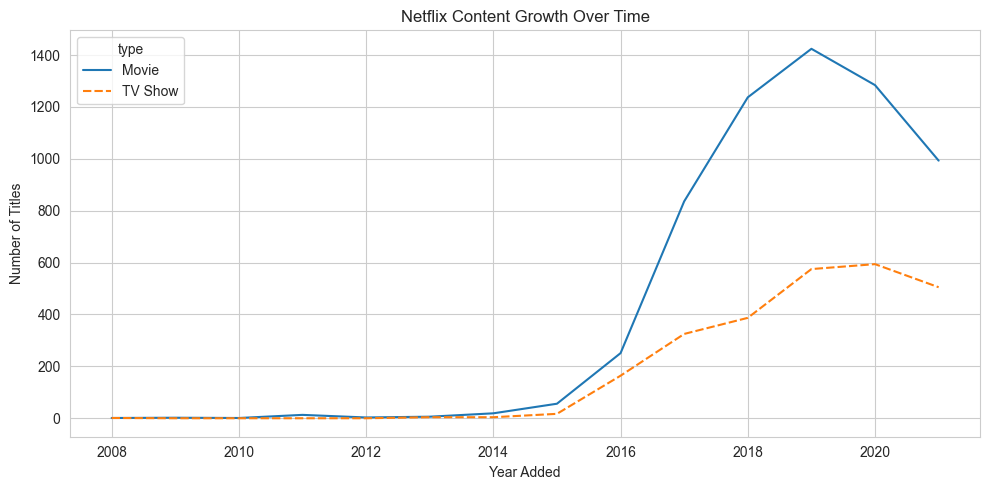

In [9]:
# VISUALIZATION 2: CONTENT GROWTH OVER TIME

plt.figure(figsize=(10, 5))

trend_data = df.groupby(['year_added', 'type']).size().unstack(fill_value=0)

sns.lineplot(data=trend_data)

plt.title("Netflix Content Growth Over Time")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")

plt.tight_layout()
plt.savefig("visuals/content_growth.png", dpi=300)
plt.show()

## Insight (Chart 2: Content Added on Netflix Over Time)

The visualization reveals a strong upward trend in the addition of Netflix content, particularly from around 2015 onward, indicating a period of rapid expansion in the platform’s content library.

While Movies consistently account for the larger share of total content, TV Shows demonstrate a noticeably faster growth rate over time. This pattern suggests a strategic shift by Netflix toward increased investment in serialized content.

This shift is likely driven by the platform’s goal to enhance viewer engagement, increase watch duration, and improve user retention, as TV series typically encourage longer and more sustained viewing patterns compared to standalone films.

## RATINGS DISTRIBUTION
We analyze how Netflix content is rated.

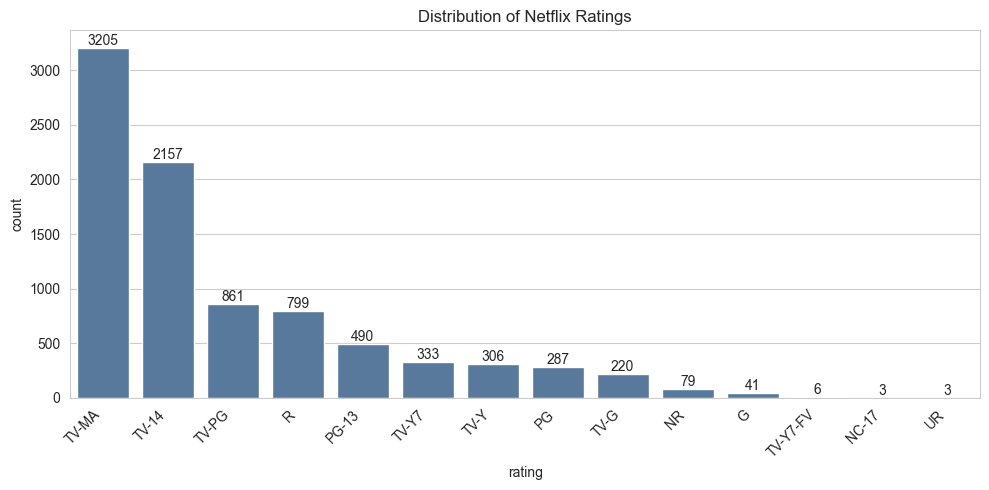

In [10]:
# VISUALIZATION 3: RATINGS DISTRIBUTION

plt.figure(figsize=(10, 5))

ratings_order = df['rating'].value_counts().index

ax = sns.countplot(
    data=df,
    x='rating',
    order=ratings_order,
    color=PRIMARY
)

ax.bar_label(ax.containers[0])

plt.title("Distribution of Netflix Ratings")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.savefig("visuals/ratings_distribution.png", dpi=300)
plt.show()


## CHART 3: NETFLIX CONTENT RATINGS DISTRIBUTION – INSIGHTS

The visualization indicates that Netflix content is predominantly concentrated within the TV-MA, TV-14, and TV-PG rating categories. This suggests a strong emphasis on content targeted toward mature audiences and teenagers, which collectively form the largest share of the platform’s library.

In contrast, ratings such as NC-17, UR, and TV-Y7-FV appear minimally within the dataset. This reflects a relatively limited presence of highly restricted or narrowly targeted content categories, including strictly children-focused or adult-restricted programming.

Overall, the distribution highlights Netflix’s strategic focus on broad, mainstream audience segments—particularly mature and adolescent viewers—while maintaining limited representation in niche rating classifications.

## TOP 10 COUNTRIES
we visualize "Top 10 Countries Producing Netflix Content"

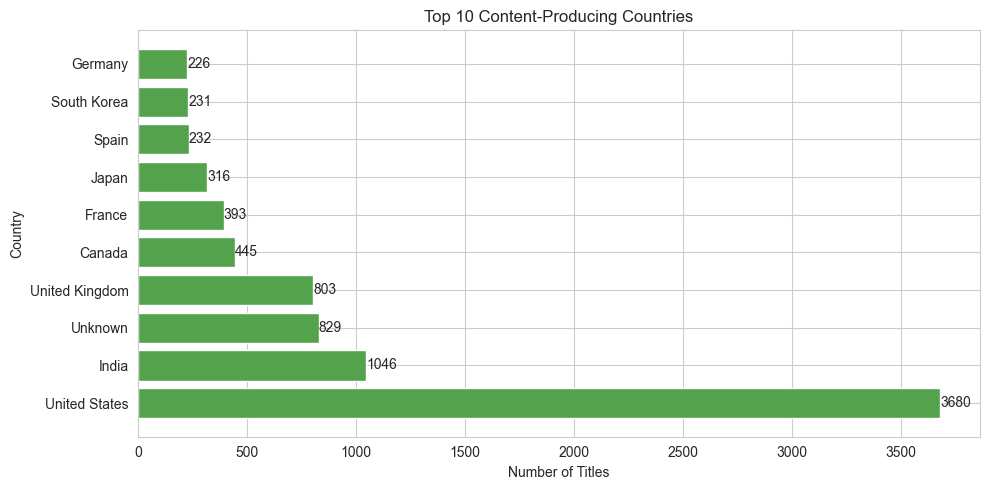

In [11]:
# VISUALIZATION 4: TOP 10 COUNTRIES

plt.figure(figsize=(10, 5))

countries = df['country'].str.split(', ').explode()
top_countries = countries.value_counts().head(10)

ax = plt.barh(top_countries.index, top_countries.values, color=ACCENT)

plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.title("Top 10 Content-Producing Countries")

plt.bar_label(ax, labels=top_countries.values)

plt.tight_layout()
plt.savefig("visuals/top_countries.png", dpi=300, bbox_inches="tight")
plt.show()

## CHART 4: INSIGHT INTERPRETATION (Top 10 Content Producing Countries on Netflix)

The visualization illustrates the top 10 countries contributing content to Netflix’s catalog. The dataset indicates that the United States dominates significantly, producing the highest number of movies and TV shows available on the platform.

Other countries such as India, the United Kingdom, and Canada also contribute a considerable share of content, reflecting Netflix’s ongoing global expansion strategy and investment in diverse markets. However, the distribution remains uneven, as most of the remaining countries show relatively lower production volumes.

Overall, the chart highlights Netflix’s strong dependence on a few major content-producing countries—particularly the United States—while still maintaining a level of international diversity in its content library.

## TOP 10 GENRES
we visualize the "Top 10 Genres on Netflix"

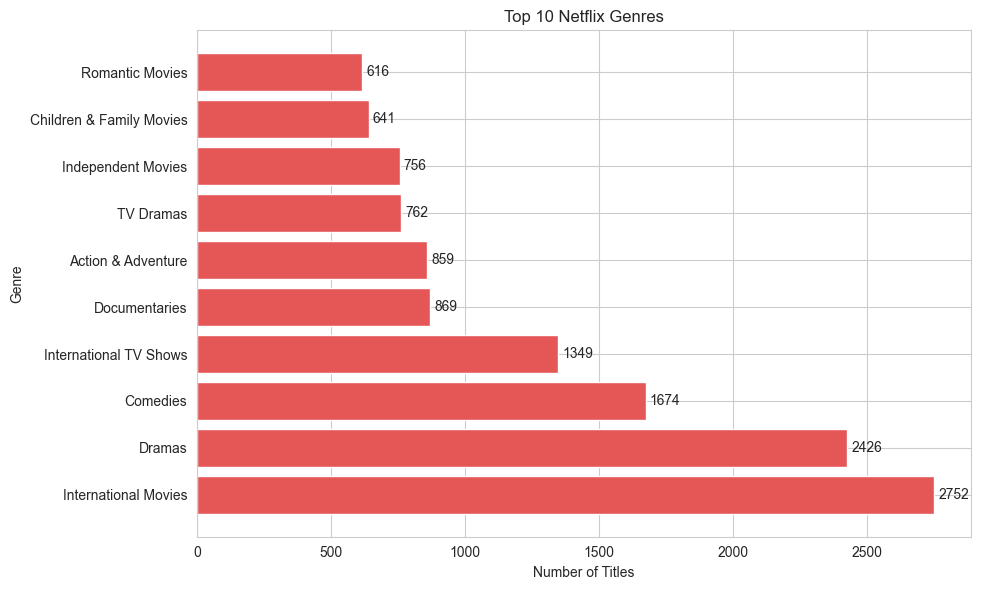

In [12]:
# VISUALIZATION 5: TOP 10 GENRES

plt.figure(figsize=(10, 6))

genres = df['listed_in'].str.split(', ').explode()
top_genres = genres.value_counts().head(10)

ax = plt.barh(top_genres.index, top_genres.values, color=DANGER)

plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.title("Top 10 Netflix Genres")

plt.bar_label(ax, labels=top_genres.values, padding=3)

plt.subplots_adjust(left=0.35)
plt.tight_layout()

plt.savefig("visuals/top_genres.png", dpi=300, bbox_inches="tight")
plt.show()

## CHART 5: INSIGHT INTERPRETATION (Top 10 Most Common Genres on Netflix)

The visualization shows that Netflix’s content library is largely dominated by **international movies, TV shows, dramas, and comedies**, indicating a strong emphasis on global appeal and mainstream entertainment.

These dominant genres reflect Netflix’s strategy of prioritizing widely consumed and highly engaging content categories that attract a broad audience base across different regions.

In contrast, niche categories such as **children’s content, family-oriented titles, and romance genres** appear less frequently. This suggests a relatively lower production or acquisition focus in these segments within the dataset.

Overall, the chart highlights Netflix’s content strategy as being heavily centered on globally appealing and high-demand genres, particularly drama and comedy, while maintaining limited representation in more specialized categories.

In [13]:
# Save cleaned dataset as CSV
df.to_csv('netflix_cleaned_dataset.csv', index=False)